# Exercises XP: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts to support intuition and transfer to other AI topics.



## Reference from the exercise

**What you will learn**  
- The differences between traditional machine learning and deep learning.
- The structure and working of artificial neural networks. How to generate, visualize, and analyze datasets with noise.
- Techniques for fitting polynomial regression models and understanding overfitting.
- The importance of cross-validation in model selection.

**What you will create**  
- A comparative table of traditional machine learning vs deep learning.
- A simple ANN diagram with labeled components.
- A noisy dataset visualized with a scatter plot.
- Polynomial regression models of varying degrees.
- A cross-validation analysis to select an optimal polynomial degree.


## 🌟 Exercise 1: Deep Learning vs Traditional Machine Learning

**As stated in the exercise**  
Objective. Understand the differences between traditional machine learning and deep learning.  
Instructions. Create a table comparing Feature Engineering, Data Processing, Scalability, Pattern Discovery, and Computational Requirements. Identify one real world problem where traditional ML is better, and one where deep learning is better. Write a short paragraph explaining why deep learning has an advantage in unstructured data processing.

**Guidance**  
Use a markdown table for the comparison, keep wording concise and concrete, then write two short examples and one paragraph in full sentences.

**To-Do:** Complete the comparison table below by filling in each cell with your own wording.


| Aspect | Traditional ML | Deep Learning |
|:--|:--|:--|
| Feature Engineering | Usually depends on human-designed features, domain rules, and manual preprocessing. | Learns useful representations directly from raw or lightly processed data. |
| Data Processing | Works very well with structured tabular data and smaller datasets. | Excels with large unstructured datasets such as images, audio, text, and video. |
| Scalability | Can be efficient on modest hardware, but performance may plateau as data complexity grows. | Often improves with more data, larger models, and GPU/TPU acceleration. |
| Pattern Discovery | Finds patterns from the provided features, so quality depends strongly on feature design. | Discovers complex nonlinear and hierarchical patterns automatically. |
| Computational Requirements | Usually lower training cost and faster experimentation. | Usually requires more memory, compute power, training time, and tuning. |

A traditional ML model is often better for credit-risk scoring on structured customer and transaction tables, because the features are already well organized, the dataset may be moderate in size, and interpretability matters. Deep learning is better for image classification, such as detecting objects in medical scans, because the important patterns are visual, high-dimensional, and difficult to describe manually. In short, traditional ML is strong when useful features are already available, while deep learning is strong when the model must learn the features itself.

Deep learning has an advantage in unstructured data processing because it performs representation learning: the model learns useful internal features instead of relying only on manually engineered variables. In images, early layers may detect edges and textures, middle layers may combine them into shapes, and deeper layers may recognize objects, creating hierarchical features. The same idea applies to text, audio, and video, where raw inputs contain complex local and global patterns. This makes deep learning especially powerful when the signal is distributed across many pixels, words, or time steps.

## 🌟 Exercise 2: Artificial Neural Networks (ANNs)

**As stated in the exercise**  
Objective. Identify and understand the key components of an ANN.  
Instructions. Draw or use a diagram tool to create an ANN with an input layer of 3 neurons, one hidden layer of 4 neurons, and an output layer of 2 neurons. Label neurons, weights, biases, activation function, and layers. Write a short description of how information flows through the network.

**Guidance**  
A clear schematic is preferred. Ensure every requested label appears exactly once and is readable.



**ANN diagram**

```mermaid
flowchart LR
    subgraph Input_Layer[Input layer: 3 neurons]
        I1((x1))
        I2((x2))
        I3((x3))
    end
    subgraph Hidden_Layer[Hidden layer: 4 neurons]
        H1((h1))
        H2((h2))
        H3((h3))
        H4((h4))
    end
    subgraph Output_Layer[Output layer: 2 neurons]
        O1((y1))
        O2((y2))
    end
    I1 -- weights --> H1
    I1 --> H2
    I1 --> H3
    I1 --> H4
    I2 --> H1
    I2 --> H2
    I2 --> H3
    I2 --> H4
    I3 --> H1
    I3 --> H2
    I3 --> H3
    I3 --> H4
    H1 -- activation function --> O1
    H1 --> O2
    H2 --> O1
    H2 --> O2
    H3 --> O1
    H3 --> O2
    H4 --> O1
    H4 --> O2
    B1[biases] -. added to weighted sums .-> H2
```

Neurons are shown as circles, the connecting lines represent weights, and biases are added before the activation function is applied.

During forward propagation, the three input values enter the input layer and are passed through weighted connections to the hidden layer. Each hidden neuron computes a weighted sum of the inputs, adds its bias, and applies an activation function to introduce nonlinearity. The hidden activations are then sent through another set of weights to the two output neurons. The output neurons again combine incoming values with weights and biases to produce the final predictions.

**Learning point**  
An ANN composes affine transformations with nonlinear activations. The affine part mixes features through weights and biases. The nonlinearity enables modeling of complex decision boundaries.


## 🌟 Exercise 3: Creating the Dataset and Visualizing the Data

**As stated in the exercise**  
Objective. Generate a dataset with noise and visualize it.  
Instructions. Import numpy, matplotlib.pyplot, and mean_squared_error from sklearn.metrics. Create 20 points using \(y = -x^2\) with Gaussian noise \(\mathcal{N}(0, 0.05)\). Plot the points with a scatter plot. Split into a training set with the first 12 points and a test set with the last 8 points.


In [1]:
# PREFILLED: just execute
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

np.random.seed(0)
x = np.arange(-1, 1, 0.1)  # 20 points from -1 to <1 step 0.1
print("x shape:", x.shape)

x shape: (20,)


In [2]:
# Generate y with Gaussian noise N(0, 0.05)
y = -x**2 + np.random.normal(loc=0, scale=0.05, size=x.shape)
print("y shape:", y.shape)

y shape: (20,)


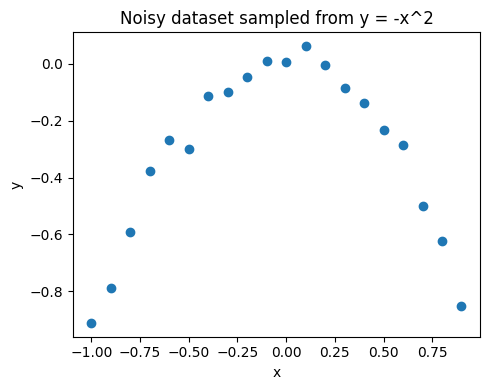

In [3]:
# PREFILLED: just execute (scatter plot of the dataset)
plt.figure(figsize=(5,4))
plt.scatter(x, y)
plt.title("Noisy dataset sampled from y = -x^2")
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [4]:
# Split into train (first 12 points) and test (last 8 points)
x_train, y_train = x[:12], y[:12]
x_test, y_test = x[12:], y[12:]
print("train sizes:", x_train.shape, y_train.shape, "test sizes:", x_test.shape, y_test.shape)

train sizes: (12,) (12,) test sizes: (8,) (8,)


**Learning point**  
Visualizing noisy data helps separate signal from noise. Splitting into train and test allows you to detect when a model overfits noise instead of learning the underlying pattern.


## 🌟 Exercise 4: Fitting Polynomial Models of Different Degrees

**As stated in the exercise**  
Objective: Fit polynomial models of varying degrees and observe overfitting.  

Instructions: Define `polynomial_fit(degree)` that returns the fitted polynomial coefficients from training data. Define `plot_polyfit(degree)` that draws the training set, the test set, and the fitted polynomial curve. Visualize fits for degrees 1, 7, and 11. Observe behavior on training and test sets as degree increases.


In [5]:
def polynomial_fit(degree: int):
    coeffs = np.polyfit(x_train, y_train, degree)
    return np.poly1d(coeffs)

In [7]:
def plot_polyfit(degree: int):
    model = polynomial_fit(degree)
    x_curve = np.linspace(x.min(), x.max(), 300)
    y_curve = model(x_curve)

    plt.figure(figsize=(6, 4))
    plt.scatter(x_train, y_train, label="train", color="tab:blue")
    plt.scatter(x_test, y_test, label="test", color="tab:orange")
    plt.plot(x_curve, y_curve, label=f"degree {degree} fit", color="tab:green")
    plt.title(f"Polynomial regression: degree {degree}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.tight_layout()
    plt.show()

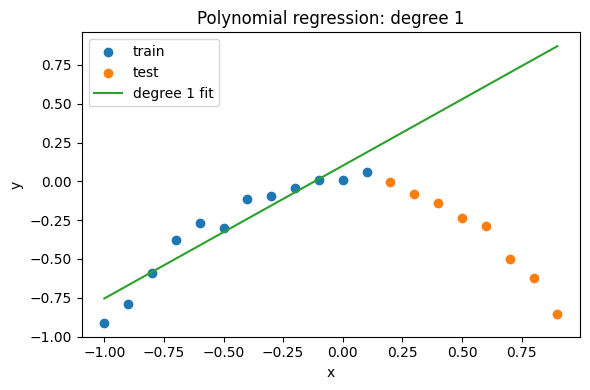

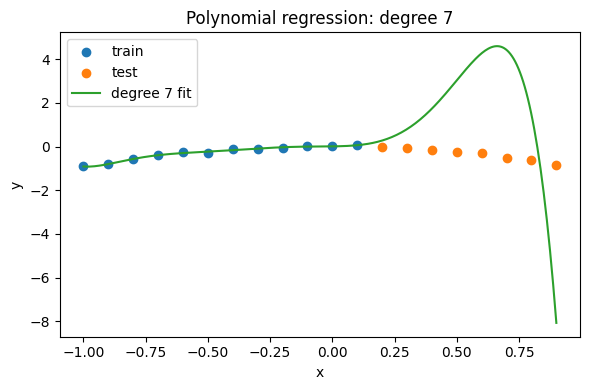

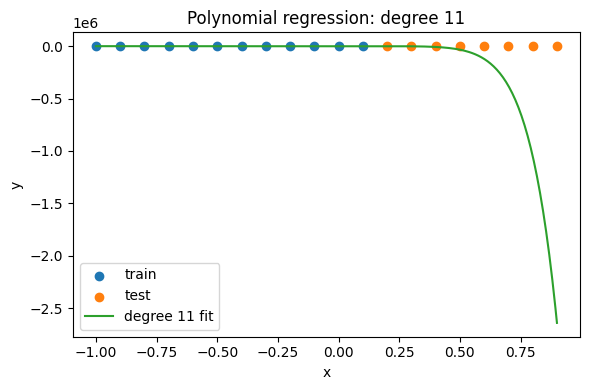

In [8]:
# Visualize degrees 1, 7, and 11
plot_polyfit(1)
plot_polyfit(7)
plot_polyfit(11)

**Learning point**  
Higher degree polynomials can perfectly fit training data yet fail to generalize. This is overfitting. You should always check test error, not just training error.

![image.png](https://github.com/user-attachments/assets/cdfb495c-066a-4efb-a361-f4b9d4ade35c)

## 🌟 Exercise 5: Cross-Validation to Find the Optimal Degree

**As stated in the exercise**  
Objective: Use cross-validation to determine the best polynomial degree.  

Instructions: Loop degrees from 1 to 11. For each degree, compute the RMSE on the training and test sets. Store results in a list. Plot RMSE vs degree with a logarithmic y axis. Identify the degree minimizing test RMSE and confirm it matches the true model \(y=-x^2\).


In [9]:
# Compute RMSE per degree for train and test
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

degrees = range(1, 12)
rows = []  # each row: (degree, rmse_train, rmse_test)

for d in degrees:
    model = polynomial_fit(d)
    rmse_train = rmse(y_train, model(x_train))
    rmse_test = rmse(y_test, model(x_test))
    rows.append((d, rmse_train, rmse_test))

rows[:3]  # peek

[(1, np.float64(0.10022633448647991), np.float64(1.0240708833556869)),
 (2, np.float64(0.04114590494650988), np.float64(0.12578064282386556)),
 (3, np.float64(0.03733692231108597), np.float64(0.7696519930800753))]

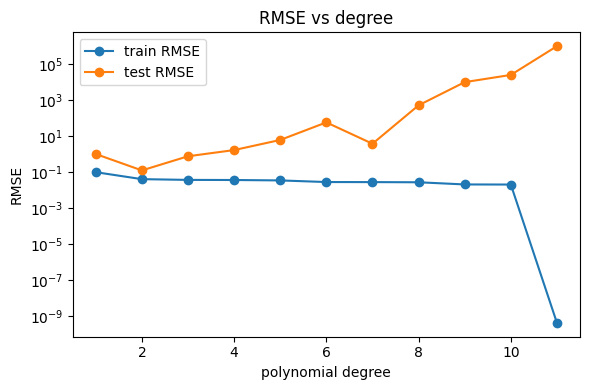

Best degree: 2, test RMSE: 0.1258


In [10]:
# Plotting RMSE curves (one figure, two curves)
degs = [r[0] for r in rows]
rmse_tr = [r[1] for r in rows]
rmse_te = [r[2] for r in rows]

plt.figure(figsize=(6, 4))
plt.plot(degs, rmse_tr, marker="o", label="train RMSE")
plt.plot(degs, rmse_te, marker="o", label="test RMSE")
plt.yscale("log")
plt.xlabel("polynomial degree")
plt.ylabel("RMSE")
plt.title("RMSE vs degree")
plt.legend()
plt.tight_layout()
plt.show()

best_degree, best_train_rmse, best_test_rmse = min(rows, key=lambda row: row[2])
print(f"Best degree: {best_degree}, test RMSE: {best_test_rmse:.4f}")

The degree with the minimum test RMSE is degree 2. This matches the true data-generating pattern, \(y=-x^2\), because a quadratic model has just enough flexibility to represent the underlying curve while ignoring most of the random noise. Lower-degree models underfit with high bias, while much higher-degree models reduce training error but increase variance and perform poorly on the test set.